## **Analisis exploratorio**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [2]:
USUARIO = "postgres"
PASSWORD = "1028"
HOST = "localhost"
PUERTO = "5432"
BASE_DATOS = "dw_analisis_criminalidad"

engine = create_engine(
    f"postgresql+psycopg2://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}"
)

print("Conexión creada correctamente.")

Conexión creada correctamente.


#### **1. Distribución territorial**

##### **1.1. Distribucion departamental**

In [3]:
query = """
SELECT
    u.departamento,
    d.tipo_delito,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_ubicacion AS u
    ON f.id_ubicacion = u.id_ubicacion
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
GROUP BY u.departamento, d.tipo_delito
ORDER BY u.departamento, cantidad_delitos DESC;
"""

df_departamento_delito = pd.read_sql(query, engine)
df_departamento_delito.head()

,departamento,tipo_delito,cantidad_delitos
0,Antioquia,Lesiones personales,180781
1,Antioquia,Violencia intrafamiliar,157423
2,Antioquia,Hurto de motocicletas y automotores,100928
3,Antioquia,Hurto a residencias y entidades comerciales,71160
4,Antioquia,Delitos sexuales,41389


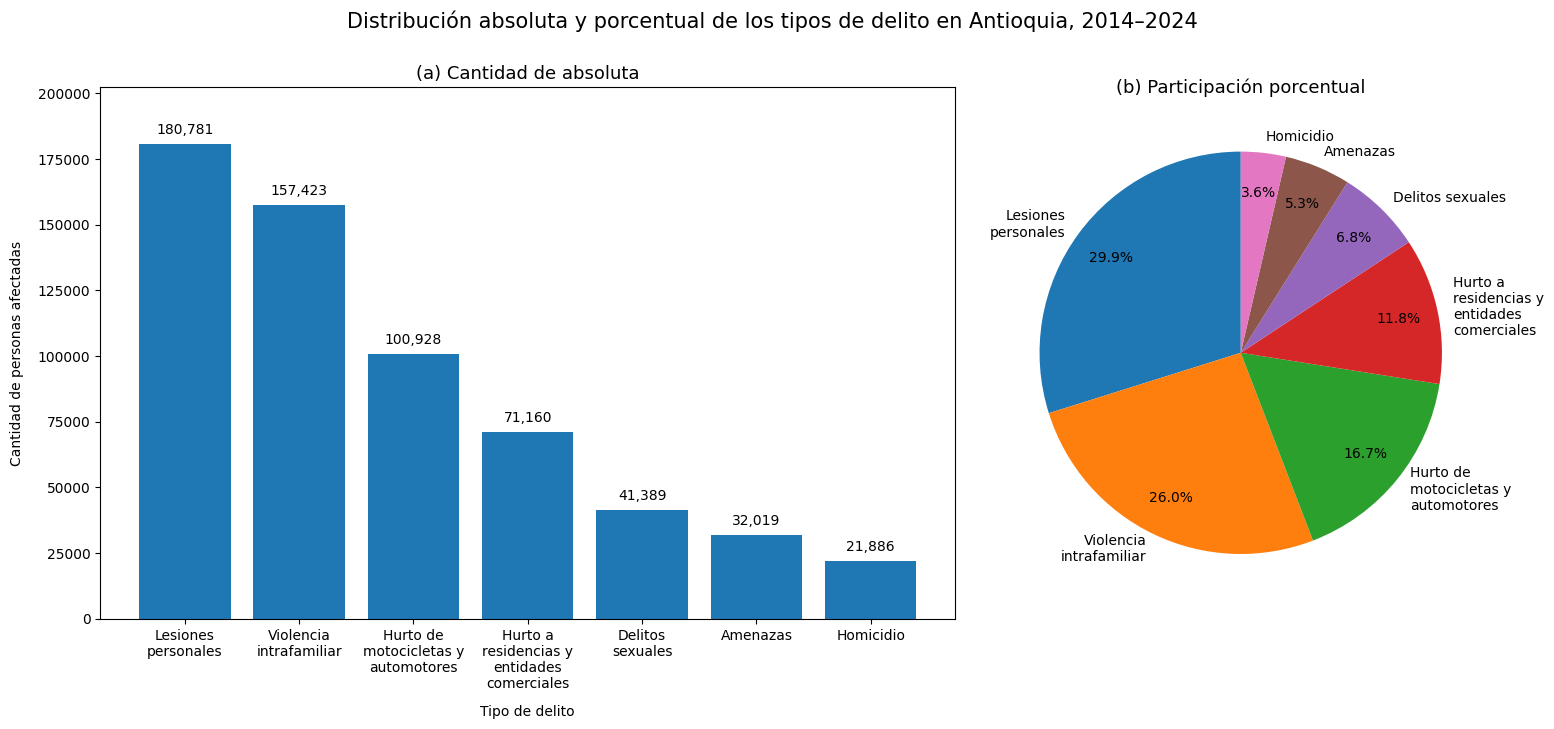

In [4]:
import matplotlib.pyplot as plt
import textwrap

# Copia de los datos
df_grafica = df_departamento_delito.copy()

# Ordenar de mayor a menor
df_grafica = df_grafica.sort_values(
    "cantidad_delitos",
    ascending=False
)

# Calcular porcentaje
df_grafica["porcentaje"] = (
    df_grafica["cantidad_delitos"] /
    df_grafica["cantidad_delitos"].sum()
) * 100

# Etiquetas para las gráficas
etiquetas_barras = [
    "\n".join(textwrap.wrap(str(delito), width=15))
    for delito in df_grafica["tipo_delito"]
]

etiquetas_torta = [
    "\n".join(textwrap.wrap(str(delito), width=18))
    for delito in df_grafica["tipo_delito"]
]

# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1.70, 1]}
)

# Controlar manualmente el espacio entre las gráficas
plt.subplots_adjust(
    wspace=0.05,
    top=0.86,
    bottom=0.10,
    left=0.08,
    right=0.95
)

# ==========================================================
# (a) DISTRIBUCIÓN ABSOLUTA
# ==========================================================

ax1.bar(
    range(len(df_grafica)),
    df_grafica["cantidad_delitos"]
)

ax1.set_title(
    "(a) Cantidad de absoluta",
    fontsize=13
)

ax1.set_xlabel(
    "Tipo de delito",
    labelpad=10
)

ax1.set_ylabel(
    "Cantidad de personas afectadas",
    labelpad=10
)

ax1.set_xticks(range(len(df_grafica)))

ax1.set_xticklabels(
    etiquetas_barras,
    rotation=0,
    ha="center"
)

max_valor = df_grafica["cantidad_delitos"].max()

ax1.set_ylim(
    0,
    max_valor * 1.12
)

for i, valor in enumerate(df_grafica["cantidad_delitos"]):
    ax1.text(
        i,
        valor + max_valor * 0.015,
        f"{valor:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ==========================================================
# (b) DISTRIBUCIÓN PORCENTUAL
# ==========================================================

ax2.pie(
    df_grafica["cantidad_delitos"],
    labels=etiquetas_torta,
    autopct="%1.1f%%",
    startangle=90,
    labeldistance=1.08,
    pctdistance=0.80
)

ax2.set_title(
    "(b) Participación porcentual",
    fontsize=13
)

# ==========================================================
# TÍTULO GENERAL
# ==========================================================

fig.suptitle(
    "Distribución absoluta y porcentual de los tipos de delito "
    "en Antioquia, 2014–2024",
    fontsize=15,
    y=0.97
)

plt.show()

In [22]:
print("Total de delitos:", df_departamento_delito["cantidad_delitos"].sum())
print("Departamentos:", df_departamento_delito["departamento"].nunique())
print("Tipos de delito:", df_departamento_delito["tipo_delito"].nunique())

Total de delitos: 605586
Departamentos: 1
Tipos de delito: 7


##### **1.2. Distribucion municipal**

In [5]:
# Consulta para obtener los 10 municipios con mayor cantidad de registros
query_top10 = """
    SELECT
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS cantidad_delitos
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.municipio,
        u.departamento
    ORDER BY
        cantidad_delitos DESC
    LIMIT 10;
"""

df_top10 = pd.read_sql(query_top10, engine)
df_top10

,municipio,departamento,cantidad_delitos
0,Medellín (Ct),Antioquia,314391
1,Bello,Antioquia,42504
2,Itagui,Antioquia,26248
3,Envigado,Antioquia,16655
4,Rionegro,Antioquia,10791
5,Apartadó,Antioquia,10440
6,Copacabana,Antioquia,9146
7,Caucasia,Antioquia,7738
8,Sabaneta,Antioquia,7647
9,Turbo,Antioquia,7440


In [6]:
query_municipios_delito = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
)

SELECT
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_ubicacion AS u
    ON f.id_ubicacion = u.id_ubicacion
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN top_municipios AS tm
    ON f.id_ubicacion = tm.id_ubicacion
GROUP BY
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    tm.total_municipio
ORDER BY
    tm.total_municipio DESC,
    cantidad_delitos DESC;
"""

df_municipios_delito = pd.read_sql(query_municipios_delito, engine)

df_municipios_delito

,municipio,departamento,tipo_delito,cantidad_delitos
0,Medellín (Ct),Antioquia,Violencia intrafamiliar,89249
1,Medellín (Ct),Antioquia,Lesiones personales,84027
2,Medellín (Ct),Antioquia,Hurto de motocicletas y automotores,67005
3,Medellín (Ct),Antioquia,Hurto a residencias y entidades comerciales,38367
4,Medellín (Ct),Antioquia,Delitos sexuales,19219
...,...,...,...,...
65,Turbo,Antioquia,Homicidio,734
66,Turbo,Antioquia,Amenazas,683
67,Turbo,Antioquia,Hurto de motocicletas y automotores,677
68,Turbo,Antioquia,Delitos sexuales,560


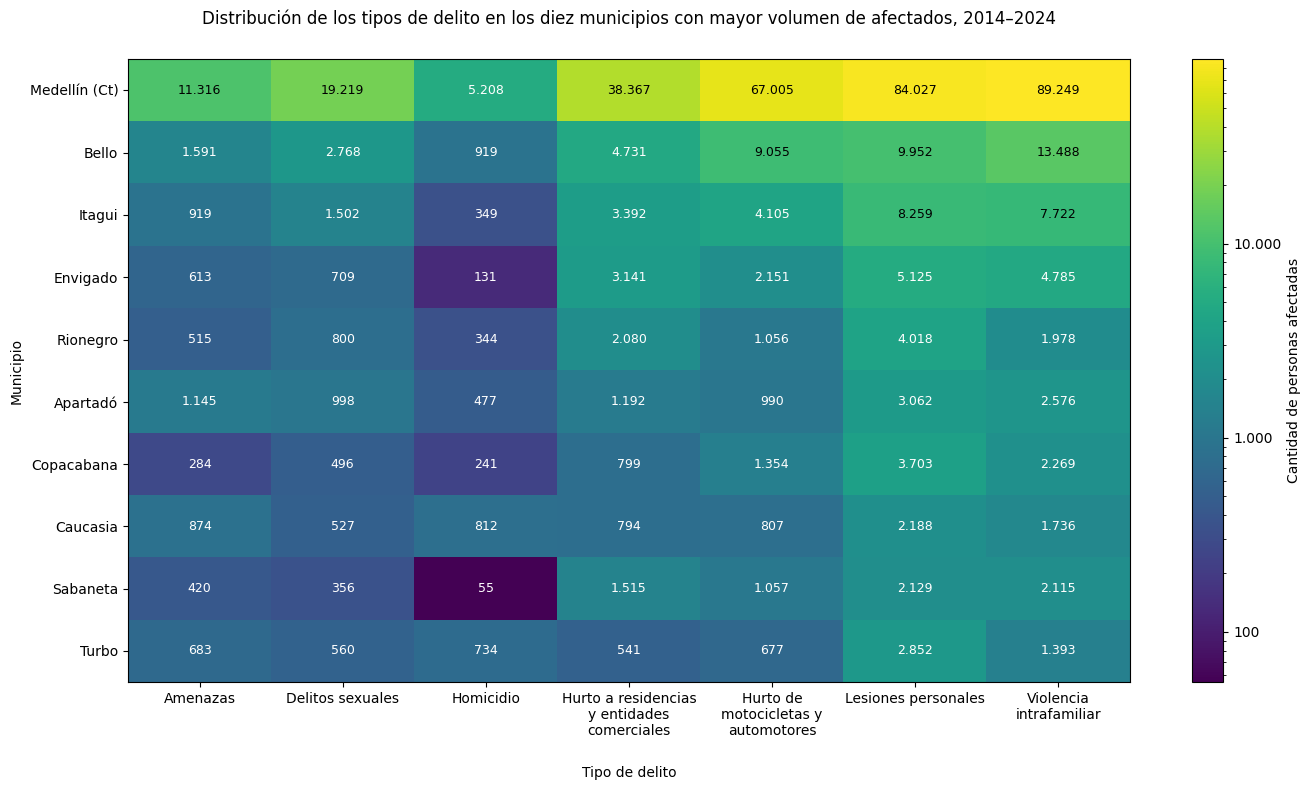

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from textwrap import fill
from matplotlib.ticker import FuncFormatter

# ==========================================================
# PREPARACIÓN DE LOS DATOS
# ==========================================================

# Crear tabla municipio x tipo de delito
tabla_heatmap = df_municipios_delito.pivot_table(
    index=["municipio", "departamento"],
    columns="tipo_delito",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

# Calcular total para ordenar los municipios
tabla_heatmap["Total"] = tabla_heatmap.sum(axis=1)

# Ordenar de mayor a menor volumen
tabla_heatmap = tabla_heatmap.sort_values("Total", ascending=False)

# Eliminar columna auxiliar
tabla_heatmap = tabla_heatmap.drop(columns="Total")

# Limpiar nombres
municipios = [
    f"{municipio}"
    for municipio, departamento in tabla_heatmap.index
]

# Convertir a matriz
datos = tabla_heatmap.to_numpy()

# ==========================================================
# ESCALA LOGARÍTMICA PARA LA INTENSIDAD DEL COLOR
# ==========================================================

# Obtener el menor valor positivo para evitar problemas con log(0)
valores_positivos = datos[datos > 0]

norm = LogNorm(
    vmin=valores_positivos.min(),
    vmax=valores_positivos.max()
)

# ==========================================================
# CREACIÓN DEL HEATMAP
# ==========================================================

# Etiquetas originales
delitos = tabla_heatmap.columns.tolist()

# Partir automáticamente las etiquetas largas en varias líneas
delitos_cortos = [
    fill(delito, width=20)
    for delito in delitos
]

fig, ax = plt.subplots(figsize=(14, 8))

imagen = ax.imshow(
    datos,
    aspect="auto",
    norm=norm
)

# Eje X: tipos de delito
ax.set_xticks(np.arange(len(delitos)))
ax.set_xticklabels(
    delitos_cortos,
    rotation=0,
    ha="center"
)

# Eje Y: municipios
ax.set_yticks(np.arange(len(municipios)))
ax.set_yticklabels(municipios)

# Etiquetas
ax.set_xlabel("Tipo de delito", labelpad=20)
ax.set_ylabel("Municipio")

ax.set_title(
    "Distribución de los tipos de delito en los diez municipios con mayor volumen de afectados, 2014–2024",
    pad=25
)

# ==========================================================
# VALORES EN LAS CELDAS
# ==========================================================

for i in range(datos.shape[0]):
    for j in range(datos.shape[1]):
        valor = datos[i, j]

        texto = f"{int(valor):,}".replace(",", ".")

        # Determinar contraste del texto según intensidad
        if valor > 0:
            # Obtener el color de fondo de la celda
            rgba = imagen.cmap(norm(valor))

            # Calcular luminancia del color
            r, g, b, _ = rgba

            luminancia = (
                0.299 * r +
                0.587 * g +
                0.114 * b
            )

            # Fondo oscuro -> texto blanco
            # Fondo claro -> texto negro
            color_texto = "white" if luminancia < 0.5 else "black"

            ax.text(
                j,
                i,
                texto,
                ha="center",
                va="center",
                fontsize=9,
                color=color_texto
            )

# ==========================================================
# BARRA DE COLOR
# ==========================================================

cbar = fig.colorbar(imagen, ax=ax)

cbar.set_label("Cantidad de personas afectadas")

cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", "."))
)

plt.tight_layout()
plt.show()

#### **2. Caracterizacion de las victimas**

##### **2.1. Caracterizacion general de las victimas**

In [10]:
query_genero = """
SELECT
    d.tipo_delito,
    v.genero,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
GROUP BY
    d.tipo_delito,
    v.genero
ORDER BY
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_genero = pd.read_sql(query_genero, engine)

print("Resultados: tipo de delito × género")
display(df_genero)

Resultados: tipo de delito × género


,tipo_delito,genero,cantidad_delitos
0,Amenazas,Masculino,18977
1,Amenazas,Femenino,12763
2,Amenazas,No reportado,279
3,Delitos sexuales,Femenino,34845
4,Delitos sexuales,Masculino,6297
5,Delitos sexuales,No reportado,247
6,Homicidio,Masculino,20200
7,Homicidio,Femenino,1686
8,Hurto a residencias y entidades comerciales,No reportado,67249
9,Hurto a residencias y entidades comerciales,Masculino,2178


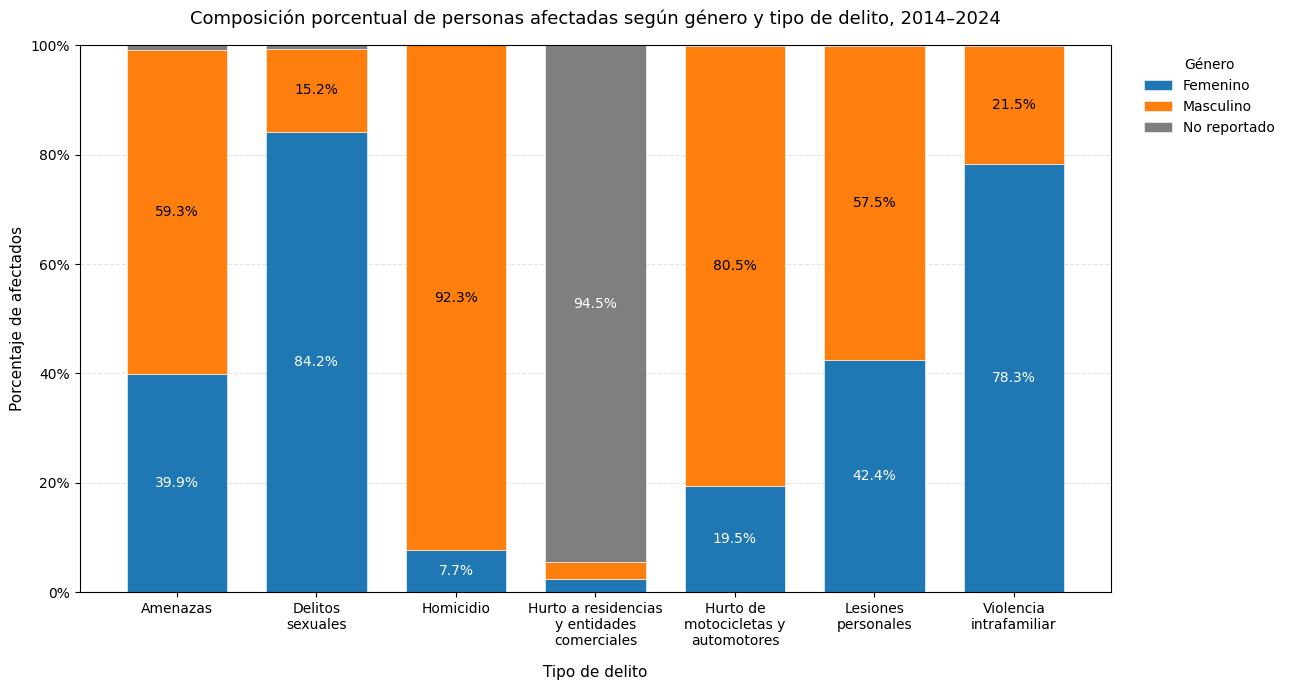

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter

# ==========================================================
# 1. PREPARACIÓN DE DATOS
# ==========================================================
tabla_genero = df_genero.pivot_table(
    index="tipo_delito",
    columns="genero",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

tabla_genero_pct = tabla_genero.div(
    tabla_genero.sum(axis=1),
    axis=0
) * 100

orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

tabla_genero_pct = tabla_genero_pct.reindex(orden_delitos)

# Orden de géneros (ajusta si tus nombres son distintos)
orden_genero = [col for col in ["Femenino", "Masculino", "No reportado"] if col in tabla_genero_pct.columns]
tabla_genero_pct = tabla_genero_pct[orden_genero]

# ==========================================================
# 2. COLORES
# ==========================================================
mapa_colores = {
    "Femenino": "#1f77b4",      # azul
    "Masculino": "#ff7f0e",     # naranja
    "No reportado": "#7f7f7f"   # gris
}

colores = [mapa_colores.get(g, "#999999") for g in orden_genero]

# ==========================================================
# 3. GRÁFICA
# ==========================================================
fig, ax = plt.subplots(figsize=(13, 7))

bottom = np.zeros(len(tabla_genero_pct))

for i, genero in enumerate(orden_genero):
    valores = tabla_genero_pct[genero].values
    barras = ax.bar(
        range(len(tabla_genero_pct)),
        valores,
        bottom=bottom,
        width=0.72,
        label=genero,
        color=colores[i],
        edgecolor="white",
        linewidth=0.4
    )

    # Color del texto según luminosidad
    r, g, b = mcolors.to_rgb(colores[i])
    luminosidad = 0.299 * r + 0.587 * g + 0.114 * b
    color_texto = "white" if luminosidad < 0.55 else "black"

    # Etiquetas solo en segmentos >= 5 %
    for j, (bar, val) in enumerate(zip(barras, valores)):
        if val >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color=color_texto,
                fontweight="medium"
            )

    bottom += valores

# ==========================================================
# 4. FORMATO
# ==========================================================
ax.set_title(
    "Composición porcentual de personas afectadas según género y tipo de delito, 2014–2024",
    fontsize=13,
    pad=15
)

ax.set_xlabel("Tipo de delito", fontsize=11, labelpad=12)
ax.set_ylabel("Porcentaje de afectados", fontsize=11)

ax.set_xticks(range(len(tabla_genero_pct)))
ax.set_xticklabels(
    [
        "Amenazas",
        "Delitos\nsexuales",
        "Homicidio",
        "Hurto a residencias\ny entidades\ncomerciales",
        "Hurto de\nmotocicletas y\nautomotores",
        "Lesiones\npersonales",
        "Violencia\nintrafamiliar"
    ],
    rotation=0,
    ha="center",
    fontsize=10
)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    title="Género",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

In [13]:
query_edad = """
SELECT
    d.tipo_delito,
    v.grupo_etario,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
GROUP BY
    d.tipo_delito,
    v.grupo_etario
ORDER BY
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_grupo = pd.read_sql(query_edad, engine)

print("Resultados: tipo de delito × grupo etario")
display(df_grupo)

Resultados: tipo de delito × grupo etario


,tipo_delito,grupo_etario,cantidad_delitos
0,Amenazas,Adultos,30955
1,Amenazas,Adolescentes,833
2,Amenazas,Menores,222
3,Amenazas,No reportado,9
4,Delitos sexuales,Adultos,25652
5,Delitos sexuales,Menores,8814
6,Delitos sexuales,Adolescentes,6890
7,Delitos sexuales,No reportado,33
8,Homicidio,Adultos,20732
9,Homicidio,Adolescentes,1066


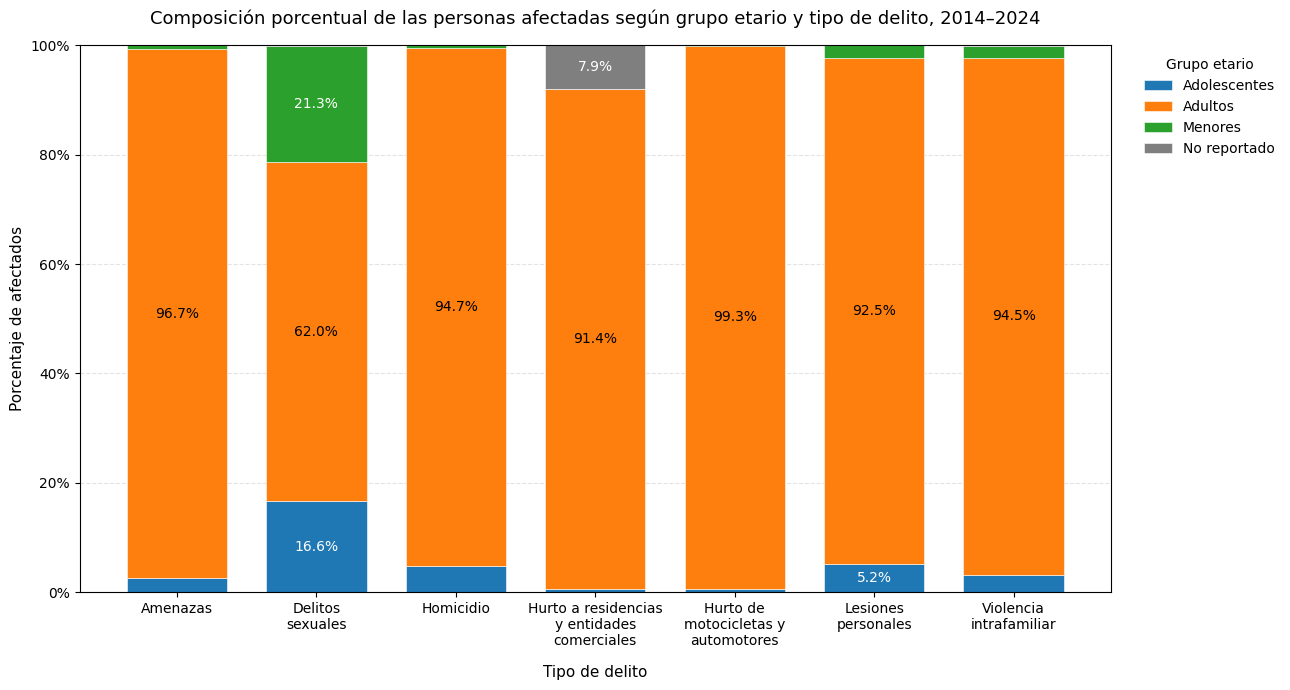

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter

# ==========================================================
# 1. PREPARACIÓN DE DATOS
# ==========================================================
tabla_edad = df_grupo.pivot_table(
    index="tipo_delito",
    columns="grupo_etario",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

tabla_edad_pct = tabla_edad.div(
    tabla_edad.sum(axis=1),
    axis=0
) * 100

orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

tabla_edad_pct = tabla_edad_pct.reindex(orden_delitos)

# Orden de grupos etarios (ajusta si el orden de columnas es distinto)
orden_grupos = [col for col in ["Adolescentes", "Adultos", "Menores", "No reportado"] if col in tabla_edad_pct.columns]
tabla_edad_pct = tabla_edad_pct[orden_grupos]

# ==========================================================
# 2. COLORES
# ==========================================================
mapa_colores = {
    "Adolescentes": "#1f77b4",   # azul
    "Adultos": "#ff7f0e",        # naranja
    "Menores": "#2ca02c",        # verde
    "No reportado": "#7f7f7f"    # gris
}

colores = [mapa_colores.get(g, "#999999") for g in orden_grupos]

# ==========================================================
# 3. GRÁFICA
# ==========================================================
fig, ax = plt.subplots(figsize=(13, 7))

bottom = np.zeros(len(tabla_edad_pct))

for i, grupo in enumerate(orden_grupos):
    valores = tabla_edad_pct[grupo].values
    barras = ax.bar(
        range(len(tabla_edad_pct)),
        valores,
        bottom=bottom,
        width=0.72,
        label=grupo,
        color=colores[i],
        edgecolor="white",
        linewidth=0.4
    )

    # Color del texto según luminosidad del segmento
    r, g, b = mcolors.to_rgb(colores[i])
    luminosidad = 0.299 * r + 0.587 * g + 0.114 * b
    color_texto = "white" if luminosidad < 0.55 else "black"

    # Etiquetas solo en segmentos >= 5 %
    for j, (bar, val) in enumerate(zip(barras, valores)):
        if val >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color=color_texto,
                fontweight="medium"
            )

    bottom += valores

# ==========================================================
# 4. FORMATO
# ==========================================================
ax.set_title(
    "Composición porcentual de las personas afectadas según grupo etario y tipo de delito, 2014–2024",
    fontsize=13,
    pad=15
)

ax.set_xlabel("Tipo de delito", fontsize=11, labelpad=12)
ax.set_ylabel("Porcentaje de afectados", fontsize=11)

ax.set_xticks(range(len(tabla_edad_pct)))
ax.set_xticklabels(
    [
        "Amenazas",
        "Delitos\nsexuales",
        "Homicidio",
        "Hurto a residencias\ny entidades\ncomerciales",
        "Hurto de\nmotocicletas y\nautomotores",
        "Lesiones\npersonales",
        "Violencia\nintrafamiliar"
    ],
    rotation=0,
    ha="center",
    fontsize=10
)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    title="Grupo etario",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

##### **2.2. Caracterizacion de victimas en los municipios con mayor volumen de registros**

In [16]:
query_municipio_genero = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
)

SELECT
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    v.genero,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
INNER JOIN top_municipios AS tm
    ON f.id_ubicacion = tm.id_ubicacion
GROUP BY
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    v.genero,
    tm.total_municipio
ORDER BY
    tm.total_municipio DESC,
    tm.municipio,
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_municipio_genero = pd.read_sql(
    query_municipio_genero,
    engine
)

print("Resultados del análisis municipio × tipo de delito × género:")
display(df_municipio_genero)

Resultados del análisis municipio × tipo de delito × género:


,municipio,departamento,tipo_delito,genero,cantidad_delitos
0,Medellín (Ct),Antioquia,Amenazas,Masculino,6245
1,Medellín (Ct),Antioquia,Amenazas,Femenino,4888
2,Medellín (Ct),Antioquia,Amenazas,No reportado,183
3,Medellín (Ct),Antioquia,Delitos sexuales,Femenino,16017
4,Medellín (Ct),Antioquia,Delitos sexuales,Masculino,3061
...,...,...,...,...,...
187,Turbo,Antioquia,Lesiones personales,Femenino,1297
188,Turbo,Antioquia,Lesiones personales,No reportado,1
189,Turbo,Antioquia,Violencia intrafamiliar,Femenino,1241
190,Turbo,Antioquia,Violencia intrafamiliar,Masculino,150


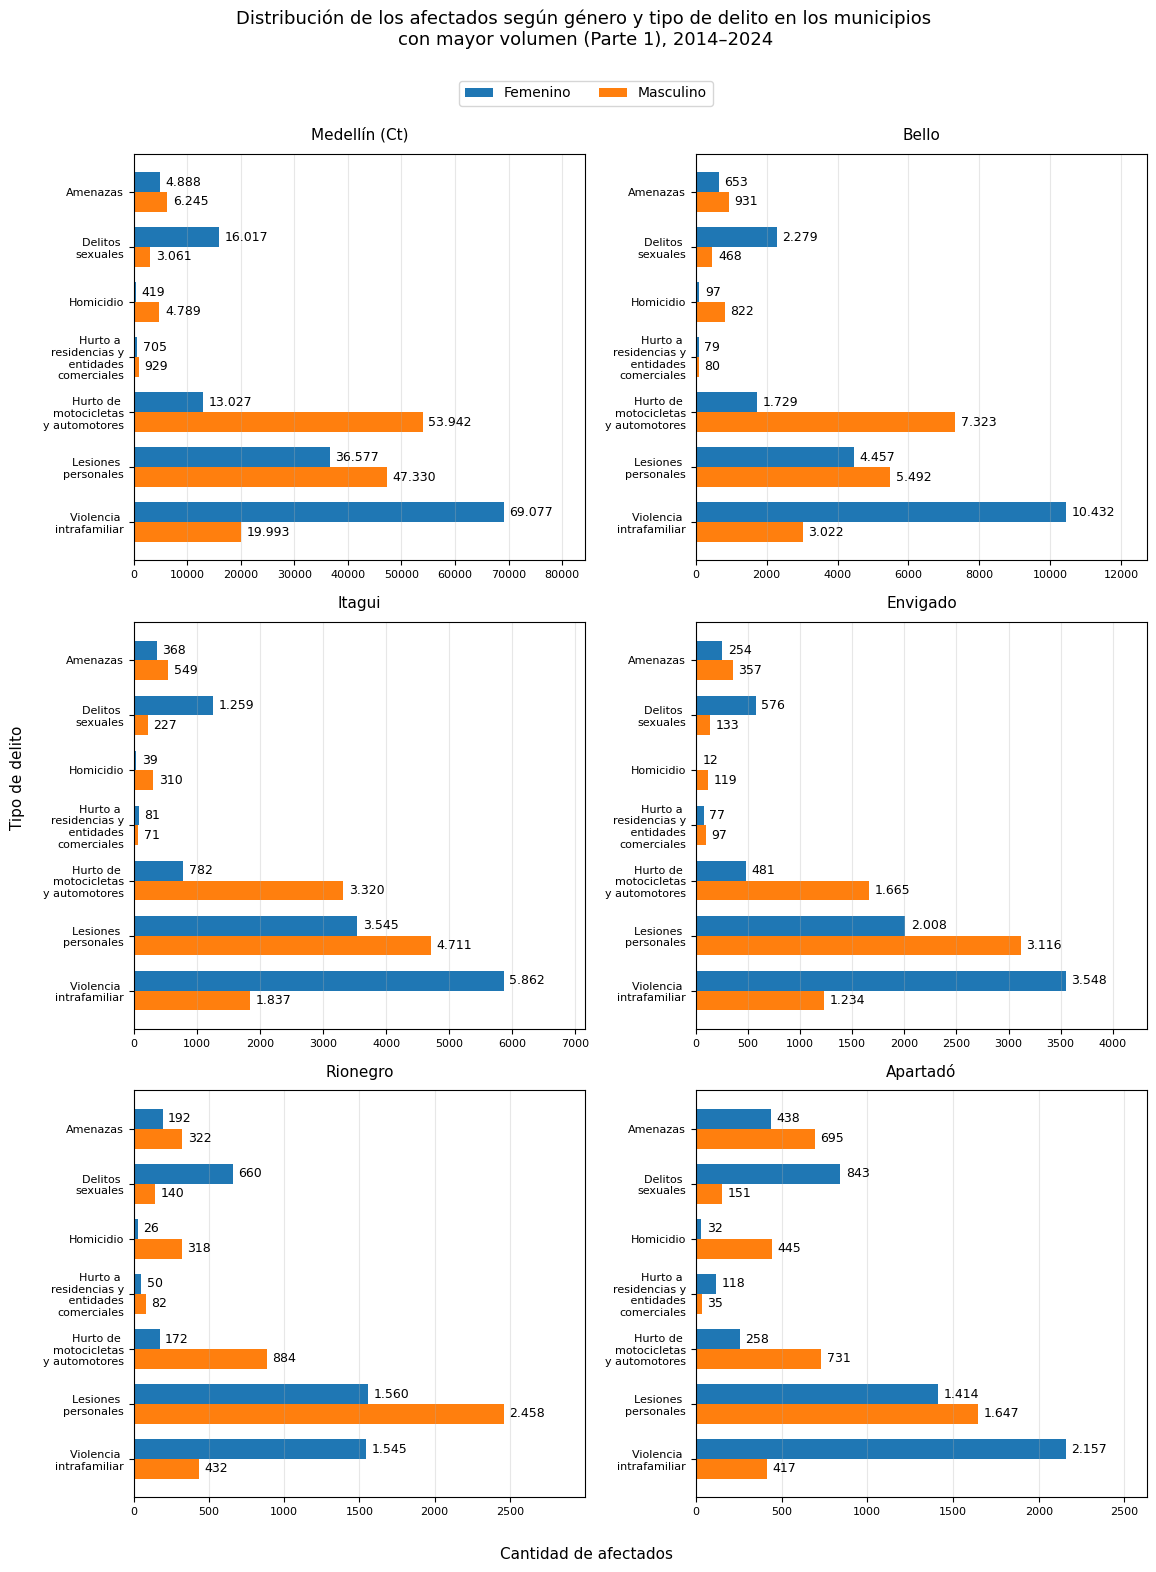

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PREPARACIÓN DE DATOS
# ==========================================================

df_plot = df_municipio_genero.copy()

df_plot["genero_limpio"] = (
    df_plot["genero"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_plot = df_plot[
    df_plot["genero_limpio"].isin(["FEMENINO", "MASCULINO"])
]

orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

etiquetas_delitos = [
    "Amenazas",
    "Delitos \nsexuales",
    "Homicidio",
    "Hurto a \nresidencias y\n entidades\ncomerciales",
    "Hurto de \nmotocicletas\ny automotores",
    "Lesiones \npersonales",
    "Violencia \nintrafamiliar"
]

orden_municipios = (
    df_municipio_genero
    .groupby(["municipio", "departamento"])["cantidad_delitos"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# ==========================================================
# FIGURA 1: 4 primeros municipios
# ==========================================================

municipios_fig1 = orden_municipios[:6]

fig1, axes1 = plt.subplots(
    3, 2,
    figsize=(12, 16)
)

axes1 = axes1.flatten()

for ax, (municipio, departamento) in zip(axes1, municipios_fig1):

    df_municipio = df_plot[
        (df_plot["municipio"] == municipio) &
        (df_plot["departamento"] == departamento)
    ]

    tabla = df_municipio.pivot_table(
        index="tipo_delito",
        columns="genero_limpio",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_delitos, fill_value=0)

    femenino = tabla.get(
        "FEMENINO",
        pd.Series(0, index=tabla.index)
    ).to_numpy()

    masculino = tabla.get(
        "MASCULINO",
        pd.Series(0, index=tabla.index)
    ).to_numpy()

    y = np.arange(len(orden_delitos))
    height = 0.36

    barras_f = ax.barh(
        y - height/2,
        femenino,
        height,
        label="Femenino",
        color="#1f77b4"
    )

    barras_m = ax.barh(
        y + height/2,
        masculino,
        height,
        label="Masculino",
        color="#ff7f0e"
    )

    # ------------------------------------------------------
    # Etiquetas de valores
    # ------------------------------------------------------

    for barra in list(barras_f) + list(barras_m):

        ancho = barra.get_width()

        if ancho > 0:
            ax.annotate(
                f"{int(ancho):,}".replace(",", "."),
                xy=(
                    ancho,
                    barra.get_y() + barra.get_height()/2
                ),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=9
            )

    # ------------------------------------------------------
    # Configuración de ejes
    # ------------------------------------------------------

    ax.set_yticks(y)
    ax.set_yticklabels(
        etiquetas_delitos,
        fontsize=8
    )

    ax.invert_yaxis()

    max_valor = max(
        femenino.max(),
        masculino.max()
    )

    ax.set_xlim(
        0,
        max_valor * 1.22
    )

    ax.ticklabel_format(
        axis="x",
        style="plain"
    )

    ax.tick_params(
        axis="x",
        labelsize=8
    )

    ax.set_title(
        municipio,
        fontsize=11,
        pad=10
    )

    ax.grid(
        axis="x",
        alpha=0.3
    )

# ==========================================================
# EJES GENERALES Y TÍTULO
# ==========================================================

fig1.supxlabel(
    "Cantidad de afectados",
    fontsize=11
)

fig1.supylabel(
    "Tipo de delito",
    fontsize=11
)

fig1.suptitle(
    "Distribución de los afectados según género y tipo de delito"
    " en los municipios \ncon mayor volumen (Parte 1), 2014–2024",
    fontsize=13
)

# ==========================================================
# LEYENDA
# ==========================================================

handles, labels = axes1[0].get_legend_handles_labels()

fig1.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
    fontsize=10
)

# ==========================================================
# AJUSTE Y MOSTRAR
# ==========================================================

plt.tight_layout(
    rect=[0.01, 0.01, 0.98, 0.95]
)

plt.show()

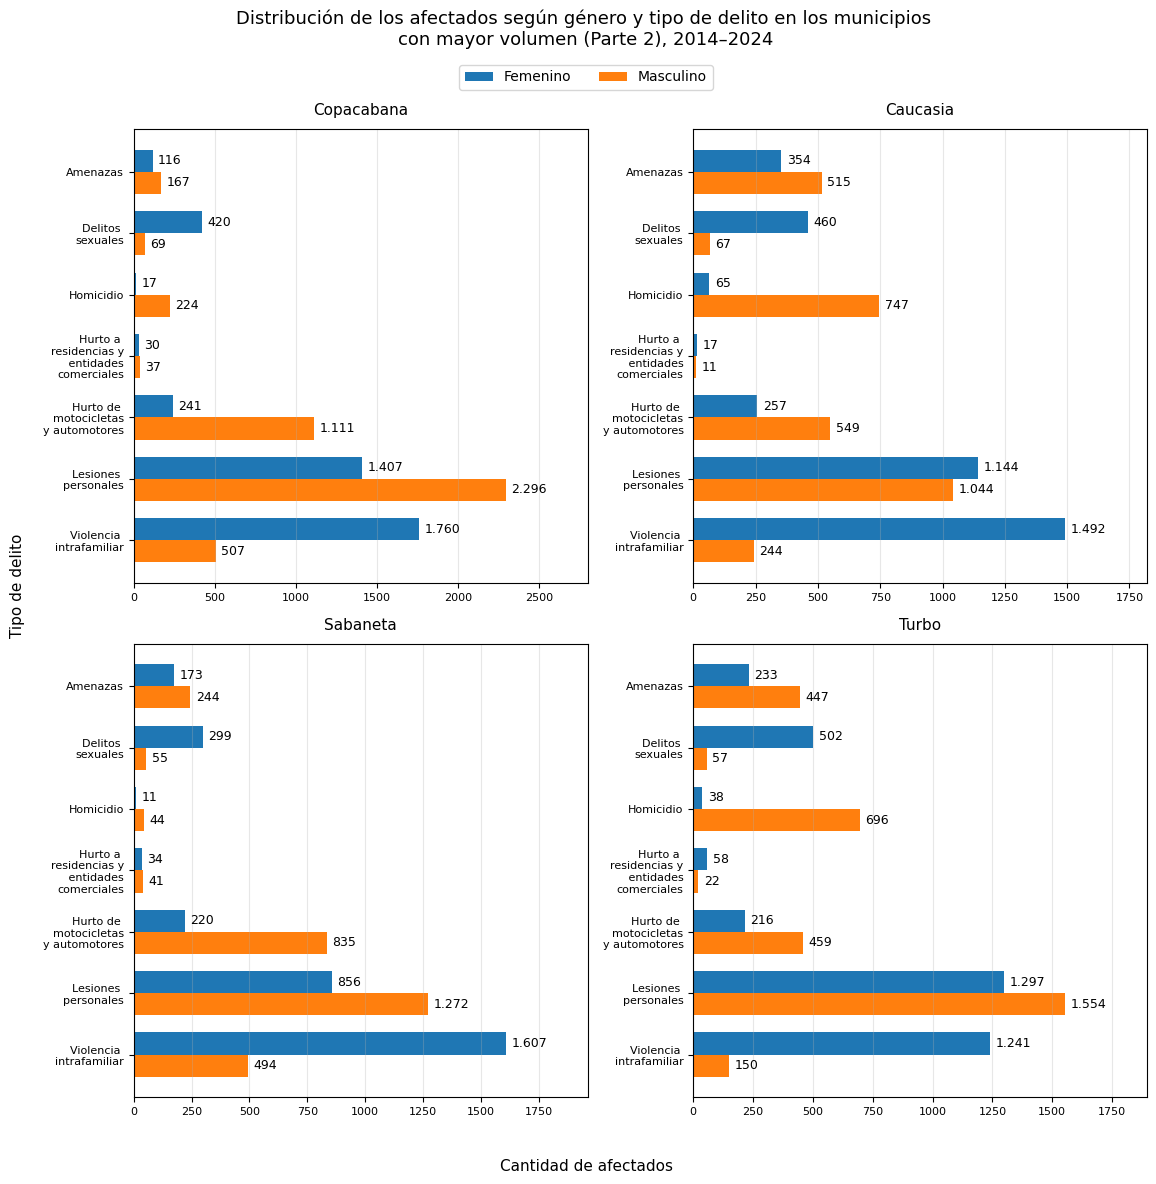

In [23]:
# ==========================================================
# FIGURA 2: Las 4 filas restantes (8 municipios)
# ==========================================================

municipios_fig2 = orden_municipios[6:12]   # Del 3º al 10º

fig2, axes2 = plt.subplots(
    2, 2,
    figsize=(12, 12)
)

axes2 = axes2.flatten()

for ax, (municipio, departamento) in zip(axes2, municipios_fig2):

    df_municipio = df_plot[
        (df_plot["municipio"] == municipio) &
        (df_plot["departamento"] == departamento)
    ]

    tabla = df_municipio.pivot_table(
        index="tipo_delito",
        columns="genero_limpio",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_delitos, fill_value=0)

    femenino = tabla.get("FEMENINO", pd.Series(0, index=tabla.index)).to_numpy()
    masculino = tabla.get("MASCULINO", pd.Series(0, index=tabla.index)).to_numpy()

    y = np.arange(len(orden_delitos))
    height = 0.36

    barras_f = ax.barh(y - height/2, femenino, height, label="Femenino", color="#1f77b4")
    barras_m = ax.barh(y + height/2, masculino, height, label="Masculino", color="#ff7f0e")

    for barra in list(barras_f) + list(barras_m):
        ancho = barra.get_width()
        if ancho > 0:
            ax.annotate(
                f"{int(ancho):,}".replace(",", "."),
                xy=(ancho, barra.get_y() + barra.get_height()/2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left", va="center",
                fontsize=9
            )

    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas_delitos, fontsize=8)
    ax.invert_yaxis()

    max_valor = max(femenino.max(), masculino.max())
    ax.set_xlim(0, max_valor * 1.22)
    ax.ticklabel_format(axis="x", style="plain")
    ax.tick_params(axis="x", labelsize=8)

    ax.set_title(municipio, fontsize=11, pad=10)
    ax.grid(axis="x", alpha=0.3)

# Ejes y leyenda Figura 2
fig2.supxlabel("Cantidad de afectados", fontsize=11)
fig2.supylabel("Tipo de delito", fontsize=11)

fig2.suptitle(
    "Distribución de los afectados según género y tipo de delito"
    " en los municipios \ncon mayor volumen (Parte 2), 2014–2024",
    fontsize=13
)

handles, labels = axes2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=2, fontsize=10)

plt.tight_layout(rect=[0.01, 0.02, 0.98, 0.96])

plt.savefig("Resultados/figura_genero_municipios_parte2.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

#### **3. Caracterizacion de delitos por medio o arma empleado**

##### **3.1. Caracterizacion general**

In [24]:
query = """
SELECT
    dd.tipo_delito,
    da.nombre_arma,
    SUM(f.cantidad_delitos) AS cantidad_registros
FROM fact_delitos f
JOIN dim_delito dd
    ON f.id_delito = dd.id_delito
JOIN dim_arma da
    ON f.id_arma = da.id_arma
GROUP BY
    dd.tipo_delito,
    da.nombre_arma
ORDER BY
    dd.tipo_delito,
    cantidad_registros DESC;
"""

df_armas = pd.read_sql(query, engine)
df_armas.head()

,tipo_delito,nombre_arma,cantidad_registros
0,Amenazas,SIN EMPLEO DE ARMAS,24335
1,Amenazas,No reportado,4112
2,Amenazas,ARMA DE FUEGO,1652
3,Amenazas,CONTUNDENTES,999
4,Amenazas,ARMA BLANCA / CORTOPUNZANTE,889


Query con filtro de porcentaje y clasificacion en otros

In [25]:
query = """
WITH datos AS (
    SELECT
        dd.tipo_delito,
        TRIM(da.nombre_arma) AS nombre_arma,
        SUM(f.cantidad_delitos) AS cantidad_registros
    FROM fact_delitos f
    JOIN dim_delito dd
        ON f.id_delito = dd.id_delito
    JOIN dim_arma da
        ON f.id_arma = da.id_arma
    GROUP BY
        dd.tipo_delito, TRIM(da.nombre_arma)
),

totales AS (
    SELECT
        tipo_delito,
        SUM(cantidad_registros) AS total_delito
    FROM datos
    GROUP BY tipo_delito
),

clasificacion AS (
    SELECT
        d.tipo_delito,
        d.nombre_arma,
        d.cantidad_registros,
        ROUND(
            100.0 * d.cantidad_registros / t.total_delito,
            3
        ) AS porcentaje,
        CASE
            WHEN LOWER(TRIM(d.nombre_arma)) = 'no reportado'
                THEN 'No reportado'

            WHEN (
                100.0 * d.cantidad_registros / t.total_delito
            ) >= 5
                THEN d.nombre_arma

            ELSE 'Otros'
        END AS categoria_grafico

    FROM datos d
    JOIN totales t
        ON d.tipo_delito = t.tipo_delito
)

SELECT
    tipo_delito,
    categoria_grafico,
    SUM(cantidad_registros) AS cantidad_registros,
    ROUND(SUM(porcentaje), 3) AS porcentaje
FROM clasificacion
GROUP BY tipo_delito, categoria_grafico
ORDER BY tipo_delito,porcentaje DESC;
"""

df_armas_categorizada = pd.read_sql(query, engine)
df_armas_categorizada.head()

,tipo_delito,categoria_grafico,cantidad_registros,porcentaje
0,Amenazas,SIN EMPLEO DE ARMAS,24335.0,76.002
1,Amenazas,No reportado,4112.0,12.842
2,Amenazas,Otros,1920.0,5.996
3,Amenazas,ARMA DE FUEGO,1652.0,5.159
4,Delitos sexuales,SIN EMPLEO DE ARMAS,25372.0,61.301


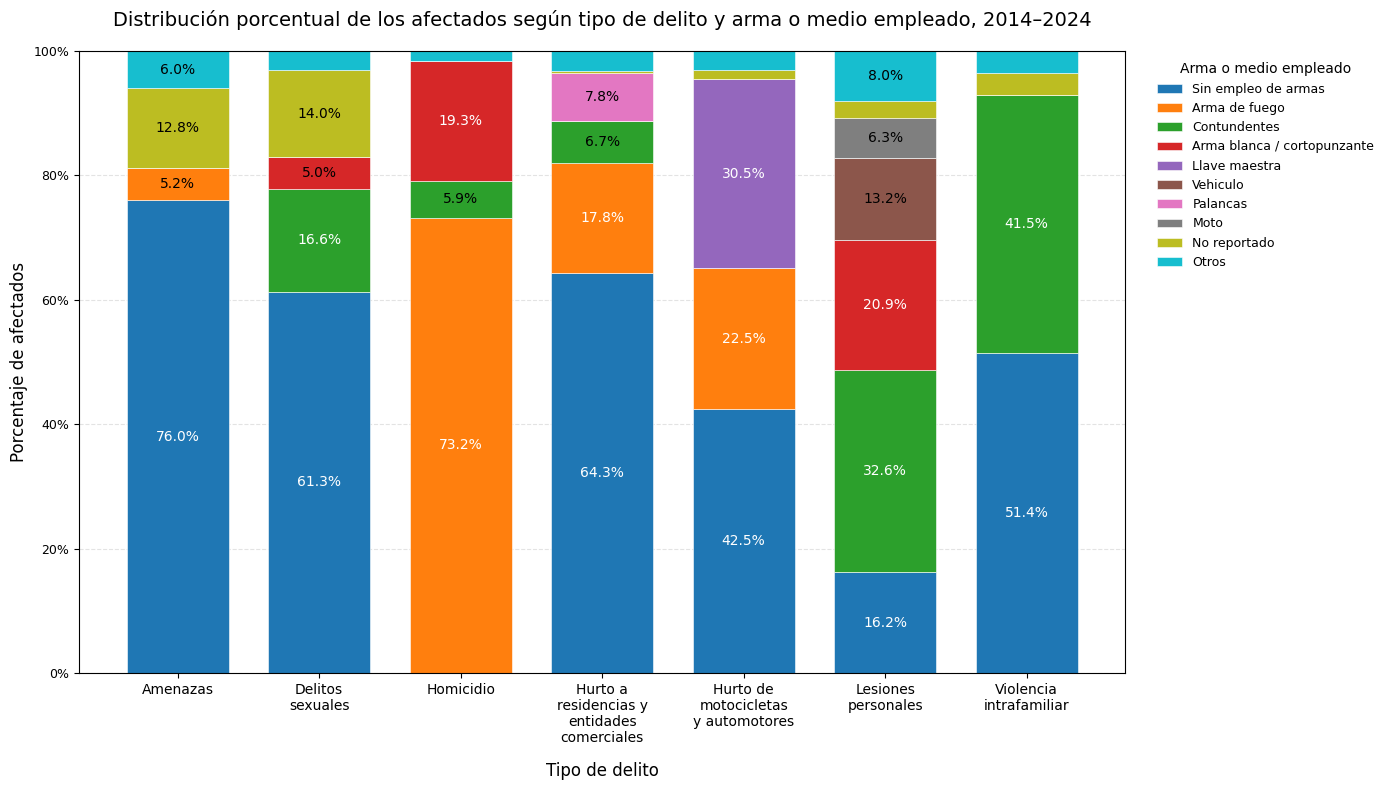

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import PercentFormatter
import numpy as np

# ==========================================================
# 1. DATOS
# ==========================================================
df = df_armas_categorizada.copy()

# ==========================================================
# 2. LIMPIEZA DE TEXTO
# ==========================================================
df["tipo_delito"] = (
    df["tipo_delito"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["categoria_grafico"] = (
    df["categoria_grafico"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
    .str.capitalize()
)

# ==========================================================
# 3. ORDEN DE LOS DELITOS
# ==========================================================
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

df["tipo_delito"] = pd.Categorical(
    df["tipo_delito"],
    categories=orden_delitos,
    ordered=True
)

# ==========================================================
# 4. TABLA PARA EL GRÁFICO
# ==========================================================
tabla = df.pivot(
    index="tipo_delito",
    columns="categoria_grafico",
    values="porcentaje"
).fillna(0)

# ==========================================================
# 5. ORDENAR CATEGORÍAS POR MAGNITUD GLOBAL (mayor → menor)
# ==========================================================
# Suma total de cada categoría a través de todos los delitos
orden_por_magnitud = tabla.sum().sort_values(ascending=False).index.tolist()

# Mover "No reportado" y "Otros" al final (mejor visualmente)
for cat in ["No reportado", "Otros"]:
    if cat in orden_por_magnitud:
        orden_por_magnitud.remove(cat)
        orden_por_magnitud.append(cat)

tabla = tabla[orden_por_magnitud]

# ==========================================================
# 6. NOMBRES PARA EL EJE X
# ==========================================================
nombres_x = [
    "Amenazas",
    "Delitos\nsexuales",
    "Homicidio",
    "Hurto a\nresidencias y\nentidades\ncomerciales",
    "Hurto de\nmotocicletas\ny automotores",
    "Lesiones\npersonales",
    "Violencia\nintrafamiliar"
]

# ==========================================================
# 7. PALETA DE COLORES MEJORADA
# ==========================================================
# Colores distintos y de buen contraste
colores_base = [
    "#1f77b4",  # azul
    "#ff7f0e",  # naranja
    "#2ca02c",  # verde
    "#d62728",  # rojo
    "#9467bd",  # morado
    "#8c564b",  # café
    "#e377c2",  # rosa
    "#7f7f7f",  # gris
    "#bcbd22",  # oliva
    "#17becf",  # cian
    "#aec7e8",  # azul claro
    "#ffbb78",  # naranja claro
]

# Asignar colores según el número de categorías
n_cats = len(orden_por_magnitud)
colores = colores_base[:n_cats]

# ==========================================================
# 8. GRÁFICO
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 8))

bottom = np.zeros(len(tabla))

for i, categoria in enumerate(orden_por_magnitud):
    valores = tabla[categoria].values
    barras = ax.bar(
        range(len(tabla)),
        valores,
        bottom=bottom,
        width=0.72,
        label=categoria,
        color=colores[i],
        edgecolor="white",
        linewidth=0.4
    )

    # Etiquetas solo en segmentos ≥ 5 %
    for j, (bar, val) in enumerate(zip(barras, valores)):
        if val >= 5:
            altura = bottom[j] + val / 2
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                altura,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="white" if val > 15 else "black",
                fontweight="medium"
            )

    bottom += valores

# ==========================================================
# 9. FORMATO
# ==========================================================
ax.set_title(
    "Distribución porcentual de los afectados según tipo de delito y arma o medio empleado, 2014–2024",
    fontsize=14,
    pad=18
)

ax.set_xlabel("Tipo de delito", fontsize=12, labelpad=12)
ax.set_ylabel("Porcentaje de afectados", fontsize=12)

ax.set_xticks(range(len(tabla)))
ax.set_xticklabels(nombres_x, rotation=0, ha="center", fontsize=10)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis="y", labelsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

# Leyenda
ax.legend(
    title="Arma o medio empleado",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

##### **3.2. Tipo de delito x Top 10 municipios x Arma o medio**

In [27]:
query = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
),

datos AS (
    SELECT
        tm.municipio,
        tm.departamento,
        dd.tipo_delito,
        TRIM(da.nombre_arma) AS nombre_arma,
        SUM(f.cantidad_delitos) AS cantidad_registros
    FROM fact_delitos AS f

    INNER JOIN top_municipios AS tm
        ON f.id_ubicacion = tm.id_ubicacion

    INNER JOIN dim_delito AS dd
        ON f.id_delito = dd.id_delito

    INNER JOIN dim_arma AS da
        ON f.id_arma = da.id_arma

    GROUP BY
        tm.municipio,
        tm.departamento,
        dd.tipo_delito,
        TRIM(da.nombre_arma)
),

totales AS (
    SELECT
        municipio,
        departamento,
        tipo_delito,
        SUM(cantidad_registros) AS total_delito
    FROM datos
    GROUP BY
        municipio,
        departamento,
        tipo_delito
),

clasificacion AS (
    SELECT
        d.municipio,
        d.departamento,
        d.tipo_delito,
        d.nombre_arma,
        d.cantidad_registros,

        ROUND(
            100.0 * d.cantidad_registros / t.total_delito,
            3
        ) AS porcentaje,

        CASE
            WHEN LOWER(TRIM(d.nombre_arma)) = 'no reportado'
                THEN 'No reportado'

            WHEN (
                100.0 * d.cantidad_registros / t.total_delito
            ) >= 5
                THEN d.nombre_arma

            ELSE 'Otros'
        END AS categoria_grafico

    FROM datos AS d

    INNER JOIN totales AS t
        ON d.municipio = t.municipio
        AND d.departamento = t.departamento
        AND d.tipo_delito = t.tipo_delito
),

resultado AS (
    SELECT
        municipio,
        departamento,
        tipo_delito,
        categoria_grafico,
        SUM(cantidad_registros) AS cantidad_registros,
        ROUND(SUM(porcentaje), 3) AS porcentaje
    FROM clasificacion
    GROUP BY
        municipio,
        departamento,
        tipo_delito,
        categoria_grafico
)

SELECT
    municipio,
    departamento,
    tipo_delito,
    categoria_grafico,
    cantidad_registros,
    porcentaje
FROM resultado
ORDER BY
    tipo_delito,
    municipio,
    porcentaje DESC;

"""
df_armas_municipios = pd.read_sql(query, engine)
df_armas_municipios.head()

,municipio,departamento,tipo_delito,categoria_grafico,cantidad_registros,porcentaje
0,Apartadó,Antioquia,Amenazas,SIN EMPLEO DE ARMAS,733.0,64.017
1,Apartadó,Antioquia,Amenazas,No reportado,308.0,26.900
2,Apartadó,Antioquia,Amenazas,Otros,104.0,9.083
3,Bello,Antioquia,Amenazas,SIN EMPLEO DE ARMAS,1251.0,78.630
4,Bello,Antioquia,Amenazas,No reportado,182.0,11.439


In [16]:
(df_armas_municipios["categoria_grafico"].unique()).tolist()

['SIN EMPLEO DE ARMAS',
 'No reportado',
 'Otros',
 'CONTUNDENTES',
 'ARMA DE FUEGO',
 'ARMA BLANCA / CORTOPUNZANTE',
 'PALANCAS',
 'LLAVE MAESTRA',
 'VEHICULO',
 'MOTO',
 'ACIDO']

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\1542109104.py:202: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = datos.pivot_table(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\1542109104.py:202: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = datos.pivot_table(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\1542109104.py:202: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = datos.pivot_table(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\1542109104.py:283: UserWarni

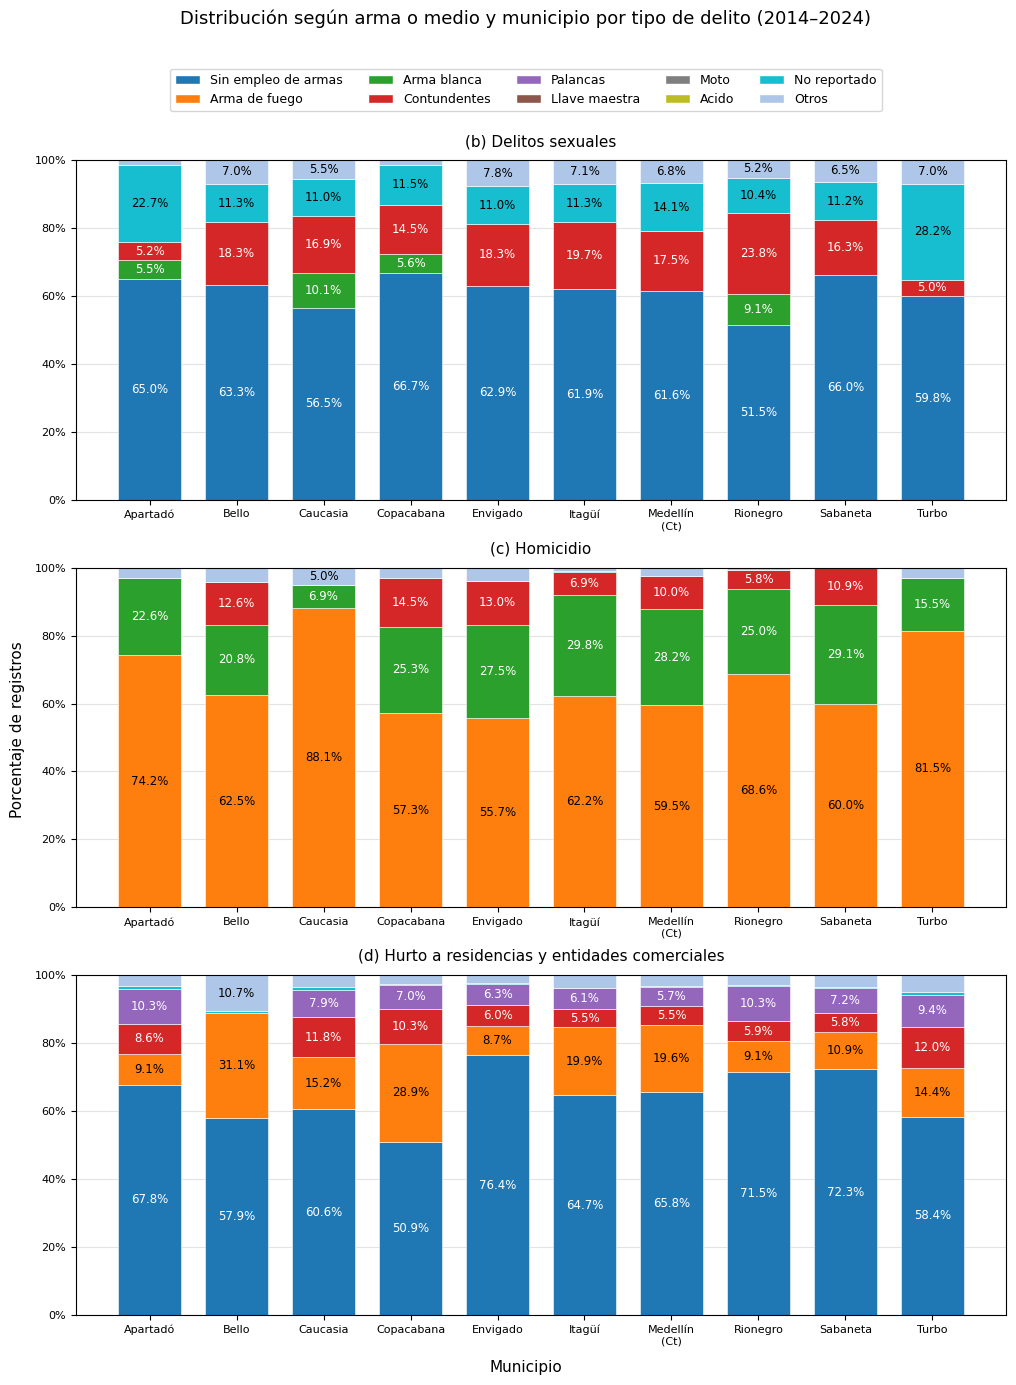

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ==========================================================
# 1. DATOS
# ==========================================================
df = df_armas_municipios.copy()

df["categoria_grafico"] = df["categoria_grafico"].replace(
    "ARMA BLANCA / CORTOPUNZANTE",
    "ARMA BLANCA"
)
df["categoria_grafico"] = (
    df["categoria_grafico"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.capitalize()
)

# ==========================================================
# 2. LIMPIEZA DE TEXTO
# ==========================================================
for columna in ["municipio", "tipo_delito", "categoria_grafico"]:
    df[columna] = (
        df[columna]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

df["municipio"] = df["municipio"].replace({
    "ApartadÃ³": "Apartadó",
    "MedellÃ­n (Ct)": "Medellín (Ct)",
    "Itagui": "Itagüí"
})

# ==========================================================
# 3. ÓRDENES
# ==========================================================
orden_municipios = [
    "Apartadó", "Bello", "Caucasia", "Copacabana", "Envigado",
    "Itagüí", "Medellín (Ct)", "Rionegro", "Sabaneta", "Turbo"
]

df["municipio"] = pd.Categorical(
    df["municipio"], categories=orden_municipios, ordered=True
)

orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

letras_figura = {
    "Amenazas": "a",
    "Delitos sexuales": "b",
    "Homicidio": "c",
    "Hurto a residencias y entidades comerciales": "d",
    "Hurto de motocicletas y automotores": "e",
    "Lesiones personales": "f",
    "Violencia intrafamiliar": "g"
}

titulos_delitos = {
    "Amenazas": "Amenazas",
    "Delitos sexuales": "Delitos sexuales",
    "Homicidio": "Homicidio",
    "Hurto a residencias y entidades comerciales": "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores": "Hurto de motocicletas y automotores",
    "Lesiones personales": "Lesiones personales",
    "Violencia intrafamiliar": "Violencia intrafamiliar"
}

orden_categorias = [
    "Sin empleo de armas", "Arma de fuego", "Arma blanca", "Contundentes",
    "Palancas", "Llave maestra", "Vehículo", "Moto", "Acido",
    "No reportado", "Otros"
]

# Categorías que realmente existen en todo el dataset de esta figura
categorias_en_datos = [
    cat for cat in orden_categorias
    if cat in df["categoria_grafico"].unique()
]

# Crear handles ficticios con los colores correctos (para la leyenda)
colores_base = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8"
]
mapa_colores = {cat: colores_base[i] for i, cat in enumerate(orden_categorias)}


handles_unificados = [
    Patch(facecolor=mapa_colores.get(cat, "#999999"), edgecolor="white", label=cat)
    for cat in categorias_en_datos
]
labels_unificados = categorias_en_datos

nombres_x = [
    "Apartadó", "Bello", "Caucasia", "Copacabana", "Envigado",
    "Itagüí", "Medellín\n(Ct)", "Rionegro", "Sabaneta", "Turbo"
]

# ==========================================================
# Función auxiliar para dibujar un panel
# ==========================================================
def dibujar_panel(ax, delito, letra, mostrar_leyenda=False):
    datos = df[df["tipo_delito"] == delito].copy()

    tabla = datos.pivot_table(
        index="municipio",
        columns="categoria_grafico",
        values="cantidad_registros",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_municipios, fill_value=0)

    categorias_presentes = [
        cat for cat in orden_categorias if cat in tabla.columns
    ]

    tabla_porcentaje = (
        tabla[categorias_presentes]
        .div(tabla[categorias_presentes].sum(axis=1), axis=0)
        * 100
    )

    bottom = np.zeros(len(tabla_porcentaje))

    for categoria in categorias_presentes:
        valores = tabla_porcentaje[categoria].values
        barras = ax.bar(
            range(len(tabla_porcentaje)),
            valores,
            bottom=bottom,
            width=0.72,
            label=categoria,
            color=mapa_colores.get(categoria, "#999999"),
            edgecolor="white",
            linewidth=0.4
        )

        color_barra = mapa_colores.get(categoria, "#999999")
        r, g, b = mcolors.to_rgb(color_barra)
        luminosidad = 0.299 * r + 0.587 * g + 0.114 * b
        color_texto = "white" if luminosidad < 0.55 else "black"

        for j, (bar, val) in enumerate(zip(barras, valores)):
            if val >= 5:
                altura = bottom[j] + val / 2
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    altura,
                    f"{val:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    color=color_texto,
                    fontweight="medium"
                )
        bottom += valores

    ax.set_title(
        f"({letra}) {titulos_delitos[delito]}",
        fontsize=11,
        pad=8
    )
    ax.set_xticks(range(len(tabla_porcentaje)))
    ax.set_xticklabels(nombres_x, rotation=0, ha="center", fontsize=8)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", alpha=0.35)
    ax.set_axisbelow(True)

    return ax

# ==========================================================
# FIGURA 1: paneles a, b, c
# ==========================================================
fig1, axes1 = plt.subplots(
    3, 1,
    figsize=(12, 15),
    gridspec_kw={"hspace": 0.20}
)

for ax, delito in zip(axes1, orden_delitos[1:4]):
    letra = letras_figura[delito]
    datos = df[df["tipo_delito"] == delito].copy()

    tabla = datos.pivot_table(
        index="municipio",
        columns="categoria_grafico",
        values="cantidad_registros",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_municipios, fill_value=0)

    categorias_presentes = [c for c in orden_categorias if c in tabla.columns]
    tabla_porcentaje = tabla[categorias_presentes].div(
        tabla[categorias_presentes].sum(axis=1), axis=0
    ) * 100

    bottom = np.zeros(len(tabla_porcentaje))
    for categoria in categorias_presentes:
        valores = tabla_porcentaje[categoria].values
        barras = ax.bar(
            range(len(tabla_porcentaje)),
            valores,
            bottom=bottom,
            width=0.72,
            label=categoria,
            color=mapa_colores.get(categoria, "#999999"),
            edgecolor="white",
            linewidth=0.4
        )
        color_barra = mapa_colores.get(categoria, "#999999")
        r, g, b = mcolors.to_rgb(color_barra)
        luminosidad = 0.299 * r + 0.587 * g + 0.114 * b
        color_texto = "white" if luminosidad < 0.55 else "black"

        for j, (bar, val) in enumerate(zip(barras, valores)):
            if val >= 5:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%",
                    ha="center", va="center",
                    fontsize=8.5, color=color_texto, fontweight="medium"
                )
        bottom += valores

    ax.set_title(f"({letra}) {titulos_delitos[delito]}", fontsize=11, pad=10)
    ax.set_xticks(range(len(tabla_porcentaje)))
    ax.set_xticklabels(nombres_x, rotation=0, ha="center", fontsize=8)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", alpha=0.35)
    ax.set_axisbelow(True)

fig1.suptitle(
    "Distribución según arma o medio y municipio por tipo de delito (2014–2024)",
    fontsize=13, y=0.98
)
fig1.supxlabel("Municipio", fontsize=11, y=0.07)
fig1.supylabel("Porcentaje de registros", fontsize=11, x=0.07)

handles_dict = {}
for ax in axes1:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in handles_dict:
            handles_dict[label] = handle

# 2. Usar el orden global, pero solo las que existen en esta figura
orden_leyenda = [
    cat for cat in orden_categorias
    if cat in handles_dict
]

handles = [handles_dict[cat] for cat in orden_leyenda]
labels = orden_leyenda

fig1.legend(
    handles_unificados, labels_unificados,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=5,
    fontsize=9
)

plt.tight_layout(rect=[0.06, 0.04, 0.98, 0.0])

plt.savefig(
    "Resultados/Figura_4-7_abc.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\2331394915.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = datos.pivot_table(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\2331394915.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = datos.pivot_table(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\2331394915.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = datos.pivot_table(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\2331394915.py:83: UserWarning: 

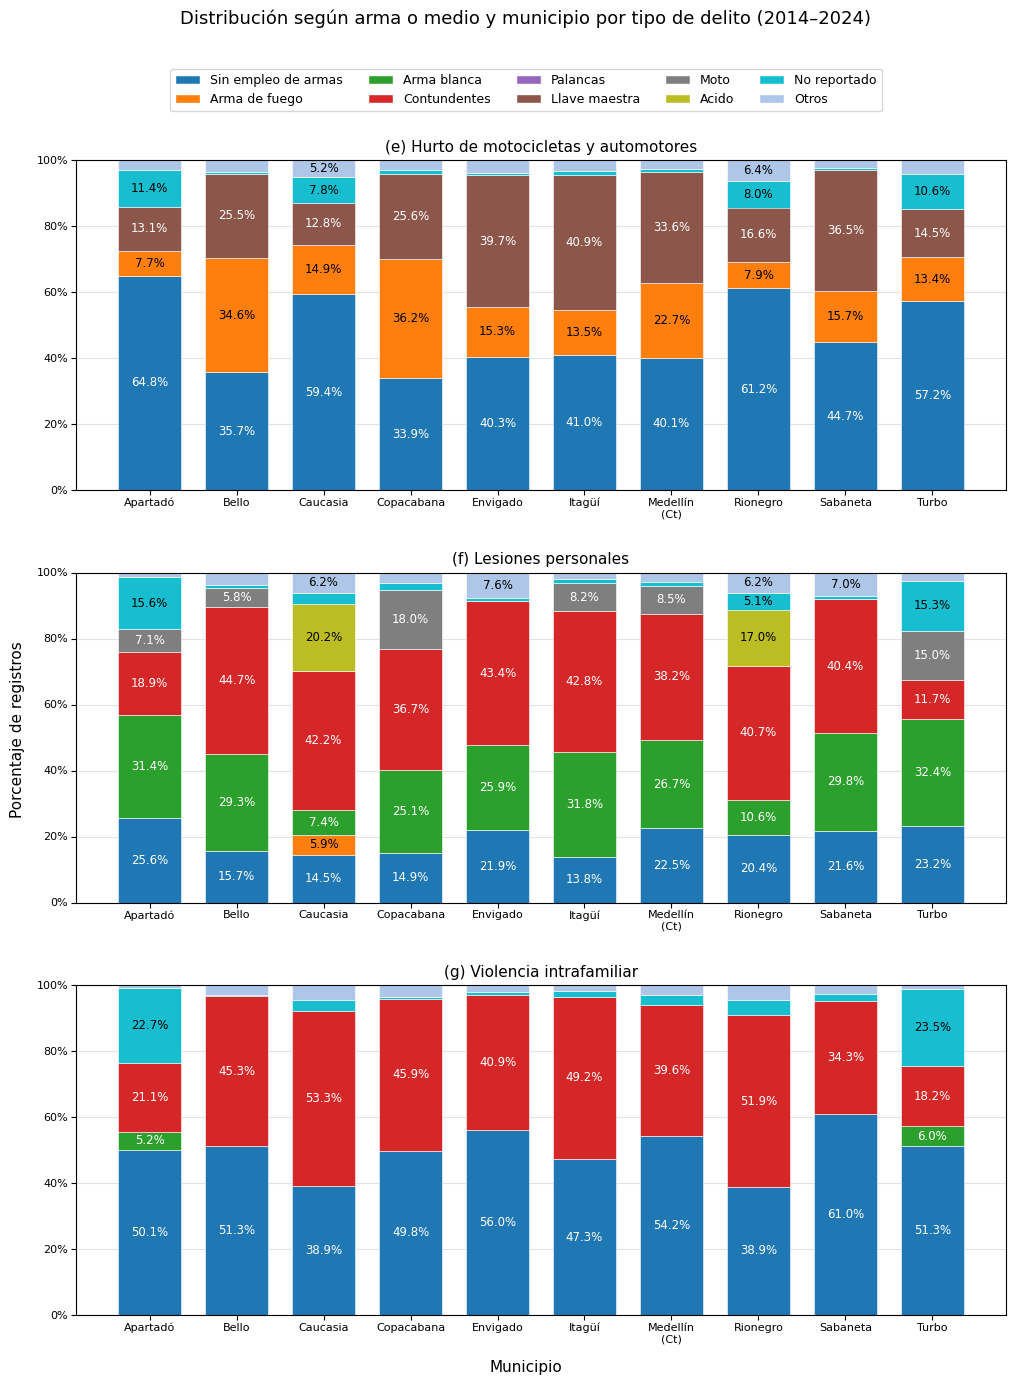

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2688\2331394915.py:102: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = datos.pivot_table(


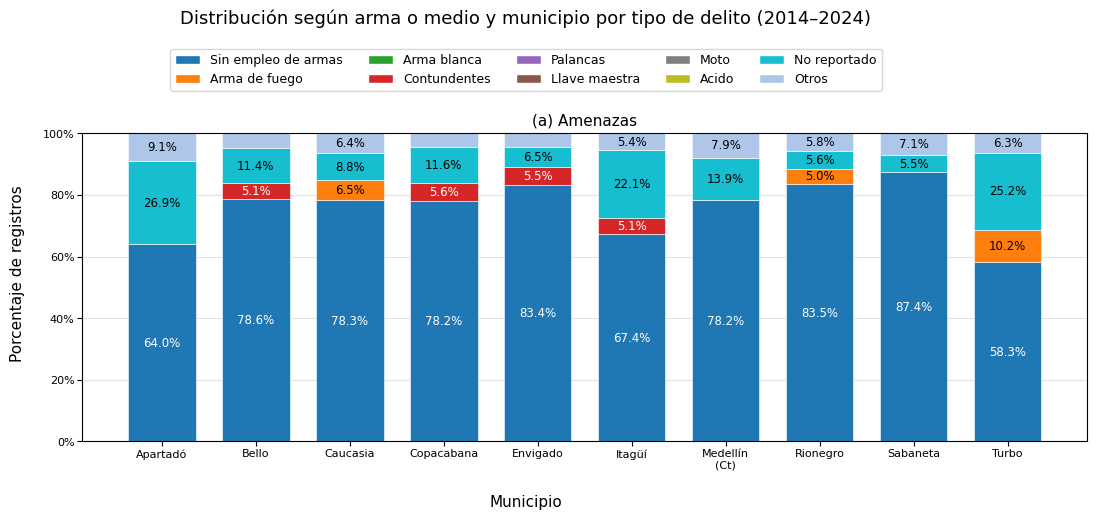

In [37]:
# ==========================================================
# FIGURA 2: paneles (d), (e), (f)
# ==========================================================
fig2, axes2 = plt.subplots(
    3, 1,
    figsize=(12, 15),
    gridspec_kw={"hspace": 0.25}
)

for ax, delito in zip(axes2, orden_delitos[4:7]):
    letra = letras_figura[delito]

    datos = df[df["tipo_delito"] == delito].copy()
    tabla = datos.pivot_table(
        index="municipio",
        columns="categoria_grafico",
        values="cantidad_registros",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_municipios, fill_value=0)

    categorias_presentes = [c for c in orden_categorias if c in tabla.columns]
    tabla_porcentaje = tabla[categorias_presentes].div(
        tabla[categorias_presentes].sum(axis=1), axis=0
    ) * 100

    bottom = np.zeros(len(tabla_porcentaje))
    for categoria in categorias_presentes:
        valores = tabla_porcentaje[categoria].values
        barras = ax.bar(
            range(len(tabla_porcentaje)),
            valores,
            bottom=bottom,
            width=0.72,
            label=categoria,
            color=mapa_colores.get(categoria, "#999999"),
            edgecolor="white",
            linewidth=0.4
        )
        color_barra = mapa_colores.get(categoria, "#999999")
        r, g, b = mcolors.to_rgb(color_barra)
        luminosidad = 0.299 * r + 0.587 * g + 0.114 * b
        color_texto = "white" if luminosidad < 0.55 else "black"

        for j, (bar, val) in enumerate(zip(barras, valores)):
            if val >= 5:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%",
                    ha="center", va="center",
                    fontsize=8.5, color=color_texto, fontweight="medium"
                )
        bottom += valores

    ax.set_title(f"({letra}) {titulos_delitos[delito]}", fontsize=11, pad=6)
    ax.set_xticks(range(len(tabla_porcentaje)))
    ax.set_xticklabels(nombres_x, rotation=0, ha="center", fontsize=8)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.tick_params(axis="x", labelsize=8, pad=2)
    ax.tick_params(axis="y", labelsize=8, pad=2)
    ax.grid(axis="y", alpha=0.35)
    ax.set_axisbelow(True)

fig2.suptitle(
    "Distribución según arma o medio y municipio por tipo de delito (2014–2024)",
    fontsize=13,
    y=0.98
)

fig2.supxlabel("Municipio", fontsize=11, y=0.07)
fig2.supylabel("Porcentaje de registros", fontsize=11, x=0.07)

fig2.legend(
    handles_unificados, labels_unificados,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=5,
    fontsize=9
)

plt.tight_layout(rect=[0.06, 0.04, 0.98, 0.90])

plt.savefig(
    "Resultados/Figura_4-7_def.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# ==========================================================
# FIGURA 3: panel (g)
# ==========================================================
fig3, ax3 = plt.subplots(figsize=(12, 5.5))

delito = orden_delitos[0]   
letra = letras_figura[delito]

datos = df[df["tipo_delito"] == delito].copy()
tabla = datos.pivot_table(
    index="municipio",
    columns="categoria_grafico",
    values="cantidad_registros",
    aggfunc="sum",
    fill_value=0
).reindex(orden_municipios, fill_value=0)

categorias_presentes = [c for c in orden_categorias if c in tabla.columns]
tabla_porcentaje = tabla[categorias_presentes].div(
    tabla[categorias_presentes].sum(axis=1), axis=0
) * 100

bottom = np.zeros(len(tabla_porcentaje))
for categoria in categorias_presentes:
    valores = tabla_porcentaje[categoria].values
    barras = ax3.bar(
        range(len(tabla_porcentaje)),
        valores,
        bottom=bottom,
        width=0.72,
        label=categoria,
        color=mapa_colores.get(categoria, "#999999"),
        edgecolor="white",
        linewidth=0.4
    )
    color_barra = mapa_colores.get(categoria, "#999999")
    r, g, b = mcolors.to_rgb(color_barra)
    luminosidad = 0.299 * r + 0.587 * g + 0.114 * b
    color_texto = "white" if luminosidad < 0.55 else "black"

    for j, (bar, val) in enumerate(zip(barras, valores)):
        if val >= 5:
            ax3.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f"{val:.1f}%",
                ha="center", va="center",
                fontsize=8.5, color=color_texto, fontweight="medium"
            )
    bottom += valores

ax3.set_title(f"({letra}) {titulos_delitos[delito]}", fontsize=11, pad=6)
ax3.set_xticks(range(len(tabla_porcentaje)))
ax3.set_xticklabels(nombres_x, rotation=0, ha="center", fontsize=8)
ax3.set_ylim(0, 100)
ax3.yaxis.set_major_formatter(PercentFormatter(100))
ax3.tick_params(axis="x", labelsize=8, pad=2)
ax3.tick_params(axis="y", labelsize=8, pad=2)
ax3.grid(axis="y", alpha=0.35)
ax3.set_axisbelow(True)

fig3.suptitle(
    "Distribución según arma o medio y municipio por tipo de delito (2014–2024)",
    fontsize=13,
    y=0.98
)

fig3.supxlabel("Municipio", fontsize=11, y=0.07)
fig3.supylabel("Porcentaje de registros", fontsize=11, x=0.07)


fig3.legend(
    handles_unificados, labels_unificados,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=5,
    fontsize=9
)

plt.tight_layout(rect=[0.06, 0.06, 0.98, 0.88])

plt.savefig(
    "Resultados/Figura_4-7_g.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()